In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
import seaborn as sns
import numpy as np

from konlpy.tag import Okt
from sklearn.preprocessing import OneHotEncoder, LabelBinarizer
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# matplotlib의 한글문제를 해결
font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
# font_name
rc('font', family=font_name)

In [ ]:
# 제목 + 본문 합치기 / 카테고리별 개수 확인
df = pd.read_csv('dataset/naver_news_category.csv')
df = df[['Title', 'Article', 'PressCompany', 'Category']]
df['Document'] = df['Title'] + ' ' + df['Article']
df = df.drop(['Title', 'Article'], axis=1)
df['Category'].value_counts(sort=False)

Category
정치       1400
경제       1400
사회       1400
생활/문화    1400
IT/과학    1400
Name: count, dtype: int64

In [4]:
# 겹치는 본문 확인
dup = df.duplicated(['Document']).value_counts()
dup

False    6972
True       28
Name: count, dtype: int64

In [5]:
# 중복 본문 제거 후 카테고리별 개수 확인
df.drop_duplicates('Document', inplace=True, ignore_index=True)
df['Category'].value_counts(sort=False)

Category
정치       1392
경제       1395
사회       1390
생활/문화    1399
IT/과학    1396
Name: count, dtype: int64

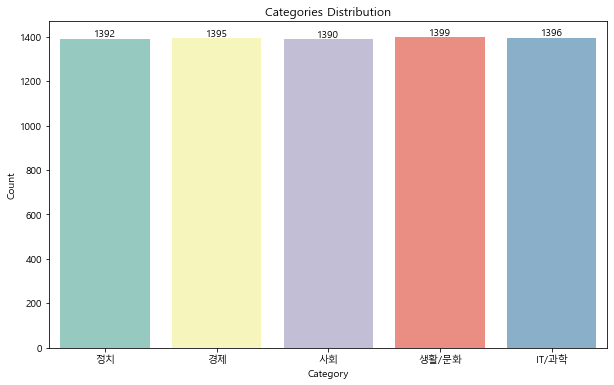

In [6]:
# 'Categories' 열의 고유한 값과 각 값의 빈도 계산
category_distribution = df['Category'].value_counts(sort=False)

# 시각화
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=category_distribution.index, y=category_distribution.values, palette="Set3")
ax.bar_label(ax.containers[0], label_type='edge', fontsize=10) # 각 막대 위에 개수 표시
plt.title('Categories Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

# 큰 차이는 없기에 언더 샘플링이나 오버 샘플링 없이 진행

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6972 entries, 0 to 6971
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   PressCompany  6972 non-null   object
 1   Category      6972 non-null   object
 2   Document      6972 non-null   object
dtypes: object(3)
memory usage: 163.5+ KB


In [8]:
df.head(3)

,PressCompany,Category,Document
0,뉴스1,정치,"日, 11년째 '독도는 일본땅' 주장…""역사·국제법상 日 고유 영토""(상보) 韓 정..."
1,파이낸셜뉴스,정치,"""김정은이 요새 대놓고 순항미사일만 쏴대는 까닭은"" 1주일 사이 3차례나 순항미사일..."
2,오마이뉴스,정치,듣도 보도 못한 TV조선의 '핼로윈 특별법' 이태원 참사 특별법을 '핼로윈 특별법'...


In [ ]:
# https://www.ranks.nl/stopwords/korean
# 텍스트 파일로 저장한 한국어 불용어 사전을 읽어오기
with open('dataset/Korean Stopwords.txt', 'r', encoding='utf-8') as file:
    stopwords = [line.strip() for line in file]

# 읽어온 불용어 리스트 확인
print(stopwords[:50])

['아', '휴', '아이구', '아이쿠', '아이고', '어', '나', '우리', '저희', '따라', '의해', '을', '를', '에', '의', '가', '으로', '로', '에게', '뿐이다', '의거하여', '근거하여', '입각하여', '기준으로', '예하면', '예를 들면', '예를 들자면', '저', '소인', '소생', '저희', '지말고', '하지마', '하지마라', '다른', '물론', '또한', '그리고', '비길수 없다', '해서는 안된다', '뿐만 아니라', '만이 아니다', '만은 아니다', '막론하고', '관계없이', '그치지 않다', '그러나', '그런데', '하지만', '든간에']


In [10]:
import re
# 추가 전처리 수행

def remove_patterns(text, patterns):
    for pattern in patterns:
        text = re.sub(pattern, ' ', text)
    return text.strip()

# 제거할 패턴 목록
patterns = [
    r'\S+@\S+',  # 이메일 주소
    r'\d{4}.\d{1,2}.\d{1,2}',  # 날짜
    r'\d{4}년 \d{1,2}월 \d{1,2}일',
    r'\w+\s+기자',
    r'https?://\S+',  # 웹사이트 URL
    r'\d{2,3}-\d{3,4}-\d{4}',  # 전화번호
    r'[▶▷■△▲◆]',
    r'제보하기\.',  # 제보 안내 문구
    r'당신의 제보가 뉴스로 만들어집니다.',  # 기타 문구
    r'\[연합뉴스 자료사진\]',  # 기타 문구
    r'Copyright \(C\) .*?\.',  # "Copyright (C) 어떤 텍스트." 제거
    r'All rights reserved\.',
    r'전화\s*:.*?',  # 전화번호 제거
    r'이메일\s*:.*?',  # 이메일 주소 제거
    r'카카오톡\s*:.*?검색',
    r'네이버, 유튜브에서 KBS뉴스를 구독해주세요!',  # 구독 안내 문구 제거
    r'전화\s*:\s*\d{2,3}-\d{3,4}-\d{4},*\s*\d{4}',  # 전화번호
    r'이메일\s*:\s*\S+@\S+',  # 이메일 주소
    r"카카오톡\s*:\s*'.*?'\s*검색,\s*채널\s*추가",  # 카카오톡 정보
    r'제보하기',  # "제보하기" 문구
    r'ⓒ',  # 저작권 표시
    r'홈페이지\s*=\s*https?://\S+',  # 웹사이트 URL
    r'당신의 제보가 뉴스로 만들어집니다\..*?제보를 기다리고 있습니다\.',  # 특정 제보 관련 문구
    r'자료사진',  # "자료사진" 문구
    r'\(자료\s*:\s*.*?\)',  # "(자료 : ...)" 문구
    r'자료\s*=\s*.*?제공',  # "자료=... 제공" 문구
    r'사진제공\s*=\s*\[.*?\]',  # "사진제공=[...]" 문구
    r'사진\s*=\s*\[.*?\]',  # "사진=[...]" 문구
    r'\[\s*사진\s*=\s*.*?\]',  # "[사진 = ...]"와 같은 패턴 제거
    r'무단 전재 및 재배포 금지\.',  # "무단 전재 및 재배포 금지." 제거
    r'\(사진\s*=\s*\)',
    r'발로 뛰는 더팩트는 24시간 여러분의 제보를 기다립니다\.',
    r'촬영기자:\s*\w+'
]

In [11]:
# DataFrame에 적용
df['Document'] = df['Document'].apply(lambda x: remove_patterns(x, patterns))

In [12]:
tokenizer = Okt()  # 형태소 분석기 초기화

# 한자를 식별하기 위한 함수
def is_hanja(character):
    return re.match(r'[\u4e00-\u9fff]', character)

# 텍스트 데이터를 전처리 (명사, 영어, 한자만 추출 & 불용어 제거)
def preprocess_text(text):
    tokens = tokenizer.pos(text)
    filtered_pos_tokens = [word for word, pos in tokens if (pos == 'Noun' or (pos == 'Foreign' and is_hanja(word)) or pos == 'Alpha') and word not in stopwords]
    return " ".join(filtered_pos_tokens)

In [43]:
from tqdm import tqdm

# tqdm 라이브러리를 사용하여 진행 상황 표시
tqdm.pandas()

# df['Document'] 열에 preprocess_text 함수 적용
df['Document'] = df['Document'].progress_apply(preprocess_text)

100%|██████████████████████████████████████████████████████████████████████████████| 6972/6972 [08:43<00:00, 13.32it/s]


In [67]:
news_organizations = ['뉴스1', '파이낸셜뉴스', '오마이뉴스', '연합뉴스', '국제신문', '뉴시스', '매일경제', '머니투데이',
       'JTBC', '아시아경제', '한국경제', '이데일리', '더팩트', '조선일보', 'SBS', '부산일보',
       '채널A', '주간조선', 'MBC', '헤럴드경제', '조세일보', '프레시안', '뉴스타파', 'KBS',
       '중앙일보', '노컷뉴스', '디지털타임스', 'YTN', '신동아', '서울경제', 'MBN', '시사저널',
       '시사IN', '세계일보', '데일리안', '서울신문', '아이뉴스24', '국민일보', '동아일보', 'TV조선',
       '강원일보', '경향신문', 'kbc광주방송', '한국일보', '대전일보', '연합뉴스TV', '미디어오늘',
       '한겨레', '조선비즈', '매일신문', '문화일보', '강원도민일보', '대구MBC', '전주MBC', 'JIBS',
       '경기일보', '머니S', '한겨레21', '여성신문', '주간동아', '중앙SUNDAY', '주간경향',
       '한국경제TV', '블로터', '비즈워치', '이코노미스트', 'SBS Biz', '디지털데일리', '전자신문',
       '한경비즈니스', '매경이코노미', '농민신문', '코메디닷컴', '더스쿠프', '일다', '기자협회보',
       'CJB청주방송', '헬스조선', '월간 산', '동아사이언스', '레이디경향', '지디넷코리아', 'km', 'TV 조선', '조선 중앙 TV']

# 본문에 있는 발행사 이름 제거
def remove_news_organizations(text):
    for org in news_organizations:
        text = re.sub(re.escape(org), '', text)
    return text.strip()

In [68]:
# tqdm 라이브러리를 사용하여 진행 상황 표시
tqdm.pandas()

# df['Document'] 열에 preprocess_text 함수 적용
df['Document'] = df['Document'].progress_apply(remove_news_organizations)

100%|████████████████████████████████████████████████████████████████████████████| 6972/6972 [00:01<00:00, 5031.99it/s]


In [ ]:
# csv 파일로 저장
df.to_csv('dataset/new_preprocessing.csv', index=False)

In [ ]:
df = pd.read_csv('dataset/new_preprocessing.csv')
df

,PressCompany,Category,Document
0,뉴스1,정치,日 독도 일본 땅 주장 역사 국제 법 日 고유 영토 상보 韓 정부 항의 한일 관계 ...
1,파이낸셜뉴스,정치,김정은 요새 순항미사일 까닭 주일 사이 차례 순항미사일 도발 유엔 안보리 대북 제재...
2,오마이뉴스,정치,보도 못 핼로윈 특별법 이태원 참사 특별법 핼로윈 특별법 칭해 정식 명칭 안 이...
3,연합뉴스,정치,이재명 오늘 신년 회견 총선 각오 민주당 지지 호소 尹 정권 비판 대안 제시 선거 ...
4,국제신문,정치,속보 尹 대통령 이태원 특별법 거부권 행사 취임 후 윤석열 대통령 이태원 특별법 이...
...,...,...,...
6967,블로터,IT/과학,흑자 달성 LG 디스플레이 과제 재무 건전 LG 디스플레이 파주 공장 전경 사진 L...
6968,머니투데이,IT/과학,하반신 마비 쥐 K 신약 영상 다리 근육 마비 질환 생명공학 硏 HSP 유전자 치료...
6969,블로터,IT/과학,경영 불안 요기 이정환 대표 사임 설 마케팅 확대 제동 불가피 이정환 요기 대표 사...
6970,디지털타임스,IT/과학,삼바 영업 익 첫 돌파 K 바이오 연대기 획 국내 제약 바이오 기업 중 최초 화이자...


### 변수 생성 (TF-IDF(본문), Word2Vec(본문), One-Hot(발행사), Label(발행사), Label(카테고리))

In [14]:
# Label : 카테고리 (target data)
label_encoder = LabelEncoder()
df['CategoryEncoded'] = label_encoder.fit_transform(df['Category'])

In [15]:
# TF-IDF ; 본문
tfidf_vectorizer = TfidfVectorizer()

# 학습 데이터에 대해 TF-IDFVectorizer 학습 및 변환
document_tfidf = tfidf_vectorizer.fit_transform(df['Document']).todense()

In [16]:
import gensim
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize

# 데이터프레임에서 'Document' 열을 가져와서 텍스트 데이터를 리스트로 변환
documents = df['Document'].tolist()

# 각 문서를 토큰화하여 리스트로 변환
tokenized_documents = [word_tokenize(document) for document in documents]

# Word2Vec 모델 생성
model = Word2Vec(sentences=tokenized_documents, vector_size=100, window=5, min_count=1, sg=0)

# 모델 학습
model.train(tokenized_documents, total_examples=len(tokenized_documents), epochs=10)

# 각 문서의 단어 벡터를 평균하여 고정 크기의 벡터로 변환
document_vectors_np = np.array([np.mean(model.wv[words], axis=0) for words in tokenized_documents])

In [17]:
# One-Hot Encoding : 발행사 
# OneHotEncoder 객체 생성
ohe = OneHotEncoder(categories='auto', handle_unknown='ignore') 

# 카테고리 열을 2차원 배열로 변환하여 원-핫 인코딩
press_ohe = ohe.fit_transform(df['PressCompany'].values.reshape(-1, 1))

In [18]:
# Label : 발행사
label_encoder = LabelEncoder()
press_label = label_encoder.fit_transform(df['PressCompany'])

### 함수 생성

In [19]:
def split_data(document, press):
    # 학습용 데이터와 테스트용 데이터로 나누기
    x_train, x_test, y_train, y_test = train_test_split(
        np.concatenate((document, press), axis=1),  # 두 특성을 결합하여 x로 사용
        np.array(df['CategoryEncoded']),  # 타겟 데이터
        test_size=0.3,  # 테스트 데이터의 비율 설정
        random_state=23  # 랜덤 시드 설정 (재현성을 위해)
    )

    # 분리된 데이터 확인
    print("학습 세트 크기:", x_train.shape, y_train.shape)
    print("테스트 세트 크기:", x_test.shape, y_test.shape)
    
    return x_train, x_test, y_train, y_test

In [20]:
def fit_model(model, x_train, x_test, y_train, y_test):
    # 모델 학습
    model.fit(x_train, y_train)
    
    # 테스트 데이터에 대한 예측
    y_pred = model.predict(x_test)

    # 정확도 스코어 계산
    accuracy = accuracy_score(y_test, y_pred)
    print("정확도:", accuracy)

    # 분류 보고서 출력
    report = classification_report(y_test, y_pred)
    print("분류 보고서:\n", report)

### 다중 로지스틱 회귀 (TF-IDF(본문), One-Hot(발행사), Label(카테고리)) 적용

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

x_train, x_test, y_train, y_test = split_data(document_tfidf, press_ohe.toarray())

# 로지스틱 회귀 모델 초기화
logistic_regression = LogisticRegression(multi_class='multinomial', max_iter=10000)

fit_model(logistic_regression, x_train, x_test, y_train, y_test)

학습 세트 크기: (4880, 46850) (4880,)
테스트 세트 크기: (2092, 46850) (2092,)
정확도: 0.8738049713193117
분류 보고서:
               precision    recall  f1-score   support

           0       0.86      0.87      0.87       442
           1       0.85      0.85      0.85       414
           2       0.85      0.86      0.85       404
           3       0.86      0.85      0.86       426
           4       0.95      0.94      0.95       406

    accuracy                           0.87      2092
   macro avg       0.87      0.87      0.87      2092
weighted avg       0.87      0.87      0.87      2092



### 다중 로지스틱 회귀 (TF-IDF(본문), Label(발행사), Label(카테고리)) 적용

In [11]:
x_train, x_test, y_train, y_test = split_data(document_tfidf, press_label.reshape(-1, 1))

# 로지스틱 회귀 모델 초기화
logistic_regression = LogisticRegression(multi_class='multinomial', max_iter=10000)

fit_model(logistic_regression, x_train, x_test, y_train, y_test)

학습 세트 크기: (4880, 46769) (4880,)
테스트 세트 크기: (2092, 46769) (2092,)
정확도: 0.8604206500956023
분류 보고서:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84       442
           1       0.84      0.83      0.84       414
           2       0.84      0.85      0.84       404
           3       0.80      0.87      0.83       426
           4       0.97      0.94      0.96       406

    accuracy                           0.86      2092
   macro avg       0.86      0.86      0.86      2092
weighted avg       0.86      0.86      0.86      2092



### SVM (TF-IDF(본문), One-Hot(발행사), Label(카테고리)) 적용

In [12]:
from sklearn.svm import SVC

x_train, x_test, y_train, y_test = split_data(document_tfidf, press_ohe.toarray())

# SVM 분류기 생성
svm_classifier = SVC()

fit_model(svm_classifier, x_train, x_test, y_train, y_test)

학습 세트 크기: (4880, 46850) (4880,)
테스트 세트 크기: (2092, 46850) (2092,)
정확도: 0.8738049713193117
분류 보고서:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86       442
           1       0.86      0.87      0.86       414
           2       0.83      0.87      0.85       404
           3       0.86      0.84      0.85       426
           4       0.97      0.93      0.95       406

    accuracy                           0.87      2092
   macro avg       0.88      0.87      0.87      2092
weighted avg       0.87      0.87      0.87      2092



In [16]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = svm_classifier.predict(x_test)

# 혼동 행렬 생성
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# 잘못 분류된 사례 찾기
misclassified = np.where(y_test != y_pred)
print("잘못 분류된 사례의 인덱스:", misclassified[0])

[[382  25  14  21   0]
 [ 34 359   8  13   0]
 [  8  18 351  20   7]
 [ 22  13  28 358   5]
 [  0   2  20   6 378]]
잘못 분류된 사례의 인덱스: [   0    2   16   18   37   46   53   54   59   65   73   78   84   91
  113  115  117  126  130  137  146  150  157  161  169  177  182  186
  191  196  199  205  217  232  239  253  260  262  264  271  289  302
  303  315  350  359  361  364  369  371  373  376  382  391  399  401
  404  416  429  430  433  434  448  457  469  473  479  481  488  490
  491  494  528  555  558  560  562  572  600  602  605  619  624  625
  631  640  656  665  667  678  680  683  685  686  693  711  718  722
  733  734  736  744  750  755  756  762  763  778  792  795  798  806
  807  809  812  816  817  829  848  852  859  860  882  893  907  911
  920  924  931  936  947  958  961  972  990  995 1000 1014 1030 1032
 1034 1041 1042 1056 1060 1063 1098 1117 1124 1131 1162 1170 1173 1177
 1186 1187 1208 1216 1221 1248 1257 1259 1268 1276 1281 1293 1295 1325
 1328 1335 1354 

In [20]:
# 각 잘못 분류된 사례에 대한 세부 정보 출력
for index in misclassified[0]:
    print(f"인덱스 {index}: 실제 레이블 = {y_test[index]}, 예측된 레이블 = {y_pred[index]}\n")

인덱스 0: 실제 레이블 = 3, 예측된 레이블 = 2

인덱스 2: 실제 레이블 = 1, 예측된 레이블 = 0

인덱스 16: 실제 레이블 = 2, 예측된 레이블 = 0

인덱스 18: 실제 레이블 = 2, 예측된 레이블 = 4

인덱스 37: 실제 레이블 = 0, 예측된 레이블 = 1

인덱스 46: 실제 레이블 = 0, 예측된 레이블 = 1

인덱스 53: 실제 레이블 = 1, 예측된 레이블 = 0

인덱스 54: 실제 레이블 = 3, 예측된 레이블 = 2

인덱스 59: 실제 레이블 = 4, 예측된 레이블 = 2

인덱스 65: 실제 레이블 = 0, 예측된 레이블 = 3

인덱스 73: 실제 레이블 = 2, 예측된 레이블 = 3

인덱스 78: 실제 레이블 = 3, 예측된 레이블 = 1

인덱스 84: 실제 레이블 = 0, 예측된 레이블 = 1

인덱스 91: 실제 레이블 = 2, 예측된 레이블 = 1

인덱스 113: 실제 레이블 = 2, 예측된 레이블 = 1

인덱스 115: 실제 레이블 = 0, 예측된 레이블 = 2

인덱스 117: 실제 레이블 = 1, 예측된 레이블 = 0

인덱스 126: 실제 레이블 = 3, 예측된 레이블 = 2

인덱스 130: 실제 레이블 = 4, 예측된 레이블 = 2

인덱스 137: 실제 레이블 = 3, 예측된 레이블 = 0

인덱스 146: 실제 레이블 = 2, 예측된 레이블 = 1

인덱스 150: 실제 레이블 = 4, 예측된 레이블 = 2

인덱스 157: 실제 레이블 = 1, 예측된 레이블 = 0

인덱스 161: 실제 레이블 = 3, 예측된 레이블 = 2

인덱스 169: 실제 레이블 = 1, 예측된 레이블 = 0

인덱스 177: 실제 레이블 = 2, 예측된 레이블 = 3

인덱스 182: 실제 레이블 = 2, 예측된 레이블 = 0

인덱스 186: 실제 레이블 = 3, 예측된 레이블 = 0

인덱스 191: 실제 레이블 = 1, 예측된 레이블 = 0

인덱스 196: 실제 레이블 = 1, 예측된 레이블 =

### SVM (Word2Vec(본문), One-Hot(발행사), Label(카테고리)) 적용

In [46]:
from sklearn.svm import SVC

x_train, x_test, y_train, y_test = split_data(document_vectors_np, press_ohe.toarray())

# SVM 분류기 생성
svm_classifier = SVC()

fit_model(svm_classifier, x_train, x_test, y_train, y_test)

학습 세트 크기: (4880, 182) (4880,)
테스트 세트 크기: (2092, 182) (2092,)
정확도: 0.8623326959847036
분류 보고서:
               precision    recall  f1-score   support

           0       0.84      0.86      0.85       442
           1       0.85      0.82      0.83       414
           2       0.82      0.85      0.83       404
           3       0.86      0.84      0.85       426
           4       0.95      0.95      0.95       406

    accuracy                           0.86      2092
   macro avg       0.86      0.86      0.86      2092
weighted avg       0.86      0.86      0.86      2092



In [47]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = svm_classifier.predict(x_test)

# 혼동 행렬 생성
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# 잘못 분류된 사례 찾기
misclassified = np.where(y_test != y_pred)
print("잘못 분류된 사례의 인덱스:", misclassified[0])

[[378  29  15  20   0]
 [ 46 341  13  13   1]
 [ 11  14 342  22  15]
 [ 15  18  33 356   4]
 [  0   1  15   3 387]]
잘못 분류된 사례의 인덱스: [   2   11   16   18   25   30   37   45   46   53   54   58   59   61
   73   84   97  113  126  130  139  157  177  182  189  196  199  209
  210  216  232  239  240  245  248  252  253  258  260  262  264  280
  302  318  324  329  337  345  347  354  359  371  372  373  377  378
  399  401  404  416  426  430  433  434  441  448  452  457  461  473
  479  485  528  530  531  534  537  547  555  558  560  562  571  572
  573  592  597  600  602  605  615  619  625  640  644  651  659  663
  665  668  670  678  681  683  685  686  693  715  718  722  726  733
  734  735  737  740  742  744  745  750  755  756  760  762  763  788
  795  798  804  806  807  810  816  817  823  829  848  857  859  882
  911  920  924  926  931  936  939  947  958  972  978  983  984  990
  995 1000 1008 1034 1041 1042 1056 1060 1071 1087 1098 1112 1117 1123
 1124 1126 1145 

### XGB (TF-IDF(본문), Label(발행사), Label(카테고리)) 적용

In [21]:
from xgboost import XGBClassifier
x_train, x_test, y_train, y_test = split_data(document_tfidf, press_label.reshape(-1, 1))

# XGBoost 분류기 생성
xgb_classifier = XGBClassifier(
    n_estimators=100,  # 부스팅 라운드 수
    max_depth=6,       # 트리 최대 깊이
    learning_rate=0.1, # 학습률
    random_state=42,    # 난수 시드
    use_label_encoder=False,
    eval_metric='merror'  # 여기에 'merror'를 설정
)

fit_model(xgb_classifier, x_train, x_test, y_train, y_test)

학습 세트 크기: (4880, 46769) (4880,)
테스트 세트 크기: (2092, 46769) (2092,)
정확도: 0.8489483747609943
분류 보고서:
               precision    recall  f1-score   support

           0       0.83      0.85      0.84       442
           1       0.83      0.82      0.83       414
           2       0.81      0.81      0.81       404
           3       0.84      0.81      0.82       426
           4       0.93      0.95      0.94       406

    accuracy                           0.85      2092
   macro avg       0.85      0.85      0.85      2092
weighted avg       0.85      0.85      0.85      2092

